# 09. LIME, Local Surrogates, and Neighborhood Sensitivity

The previous notebook studied SHAP values: additive attributions based on Shapley values and a chosen background distribution. This notebook studies a different family of local explanation methods: **local surrogate models**, with LIME as the canonical example.

LIME asks a simple and powerful question:

> Near this case, can a simple interpretable model approximate the behavior of the black-box model?

The answer can be extremely useful for debugging, stakeholder communication, and audit review. But the phrase **near this case** hides most of the difficulty. The explanation depends on how we perturb the case, how we measure distance, how quickly weights decay with distance, and whether the local surrogate actually fits the black-box behavior in that neighborhood.

The decision-science framing is therefore:

> LIME is a local approximation to a fitted model, not a causal explanation and not a guaranteed stable reason for action.


## Learning Objectives

By the end of this notebook, you should be able to:

1. Define LIME as a weighted local surrogate optimization problem.
2. Implement a tabular LIME-style explanation from first principles.
3. Measure local surrogate fidelity using weighted error and weighted $R^2$.
4. Explain why kernel width, perturbation design, random seed, and feature scaling affect explanations.
5. Compare LIME with SHAP and permutation importance at a conceptual level.
6. Identify when a local explanation is useful and when it gives false reassurance.
7. Write a decision-science explanation report that includes uncertainty and caveats.


## 1. The LIME Objective

Let $f$ be a fitted black-box model and let $x_0$ be the case we want to explain. LIME generates perturbed points $z_1,\dots,z_m$ near $x_0$, evaluates the black-box model at those points, and fits a simple model $g$ that approximates $f$ locally.

A common mathematical expression is

$$
\hat g
= \arg\min_{g\in\mathcal G}
\sum_{i=1}^{m}\pi_{x_0}(z_i)\left(f(z_i)-g(z_i)\right)^2
+ \Omega(g),
$$

where:

- $\mathcal G$ is a class of interpretable models, often sparse linear models;
- $\pi_{x_0}(z_i)$ is a proximity weight that gives more influence to points near $x_0$;
- $\Omega(g)$ penalizes complexity, for example by limiting the number of displayed features or using regularization.

A common kernel is

$$
\pi_{x_0}(z)
= \exp\left(-\frac{d(x_0,z)^2}{\sigma^2}\right),
$$

where $d(x_0,z)$ is a distance in an interpretable feature space and $\sigma$ is the kernel width.

Ribeiro, Singh, and Guestrin (2016) introduced LIME to explain individual predictions of any classifier using locally weighted interpretable approximations. Later work on anchors and related methods emphasizes that local explanations depend strongly on the perturbation distribution and on whether the explanation has high local fidelity (Ribeiro et al., 2018; Zhao et al., 2020).


## 2. What A Local Surrogate Explains

| Question | LIME-style answer | What it does not answer |
|---|---|---|
| Why did this prediction happen? | Which local feature directions best approximate the fitted model near this case | Which feature caused the real-world outcome |
| How should I read the coefficients? | As slopes of a local surrogate, in the surrogate feature representation | As coefficients of the original black-box model |
| Is the explanation faithful? | Only if local fidelity is high in the weighted neighborhood | Fidelity outside the local neighborhood |
| Is the explanation stable? | Only after checking random seeds, kernel widths, and perturbation designs | Stability by default |
| Is the action safe? | LIME can suggest what the model is locally sensitive to | Whether intervening on that feature is feasible, ethical, or causal |

A local surrogate is most useful when the report includes the neighborhood definition, local fidelity, and sensitivity checks. Without those, a tidy coefficient chart can be misleading.


In [1]:
# Section focus: 2. What A Local Surrogate Explains.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

import os
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-cache')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, log_loss, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 9

RANDOM_SEED = 2055
rng = np.random.default_rng(RANDOM_SEED)

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 120)


def smart_display(df, precision=3, max_width='360px'):
    """Display a table with wrapped text for cleaner rendered notebook output.
    
    Parameters
    ----------
    obj : object
        Data frame, series, or displayable object that should be shown in the notebook.
    max_width : object
        Maximum text width used before long table entries wrap across lines.
    max_rows : object
        Maximum number of rows shown when the object is a data frame.
    
    Returns
    -------
    object
        Display handle or formatted notebook output created from the supplied object.
    """
    if not isinstance(df, pd.DataFrame):
        display(df)
        return
    styler = df.style.set_table_styles(
        [{'selector': 'th', 'props': [('white-space', 'normal'), ('text-align', 'left')]}]
    ).set_properties(**{
        'white-space': 'normal',
        'max-width': max_width,
        'text-align': 'left',
        'vertical-align': 'top',
    })
    display(styler.format(precision=precision))


This result is an interpretation diagnostic. For What A Local Surrogate Explains, look at whether the explanation is stable, plausible, and useful for stakeholder review. A cautious explanation is still useful when it directs better review.


## 3. Synthetic Decision Case: Renewal-Risk Triage

We will use the same business frame as the SHAP notebook: a customer-success team uses a prediction model to prioritize accounts for renewal-risk review.

The data include nonlinearities and correlated operational signals so that local explanations are meaningful and imperfect.

| Design element | Why it matters for LIME |
|---|---|
| Adoption and training gaps are correlated | Perturbing them independently can create unrealistic local examples |
| Tickets and incidents measure support burden | Local credit can move between correlated burden features |
| Risk increases nonlinearly with incident burden | A local linear approximation can fit one region well and another poorly |
| A random noise feature is included | It should not consistently appear as a top local driver |


In [2]:
# Section focus: 3. Synthetic Decision Case: Renewal-Risk Triage.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def sigmoid(z):
    """Map a linear score to a probability-like value for the notebook simulation.
    
    Parameters
    ----------
    z : object
        Linear predictor or standardized score being transformed by this helper.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the sigmoid calculation.
    """
    return 1 / (1 + np.exp(-z))


def make_renewal_data(n=5600, seed=2055):
    """Construct the renewal data helper used in the 09. LIME, Local Surrogates, and Neighborhood Sensitivity workflow.
    
    Parameters
    ----------
    n : object
        Number of observations or simulation units used by the calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(seed)

    account_size = rng.normal(0, 1, n)
    international_region = rng.binomial(1, 0.27, n)
    enterprise_segment = rng.binomial(1, sigmoid(-0.45 + 0.90 * account_size), n)

    maturity = rng.normal(0, 1, n) + 0.32 * enterprise_segment - 0.16 * international_region
    adoption = np.clip(sigmoid(0.60 * maturity + rng.normal(0, 0.62, n)), 0.02, 0.98)
    training = np.clip(sigmoid(0.72 * maturity + rng.normal(0, 0.58, n)), 0.02, 0.98)
    adoption_gap = 1 - adoption
    training_gap = 1 - training

    support_intensity = np.exp(0.38 + 0.95 * adoption_gap + 0.35 * training_gap + 0.25 * international_region)
    support_tickets_30d = rng.poisson(np.clip(support_intensity, 0.05, 12))
    recent_incidents_90d = rng.poisson(np.exp(-1.25 + 0.36 * support_tickets_30d + 0.65 * training_gap))
    recent_incidents_90d = np.clip(recent_incidents_90d, 0, 9)

    billing_delay_days = np.clip(rng.gamma(shape=1.45, scale=2.0, size=n) + 0.90 * international_region + 0.85 * adoption_gap, 0, 18)
    executive_sponsor = rng.binomial(1, sigmoid(-0.70 + 0.70 * enterprise_segment + 0.40 * account_size - 0.55 * adoption_gap), n)
    random_noise_feature = rng.normal(0, 1, n)

    logit = (
        -4.85
        + 2.35 * adoption_gap
        + 1.00 * training_gap
        + 0.18 * support_tickets_30d
        + 0.66 * recent_incidents_90d
        + 0.10 * billing_delay_days
        - 0.58 * executive_sponsor
        + 0.20 * international_region
        + 0.34 * adoption_gap * np.log1p(support_tickets_30d)
        + 0.13 * np.maximum(recent_incidents_90d - 3, 0) ** 1.25
        + rng.normal(0, 0.18, n)
    )
    renewal_risk_probability = sigmoid(logit)
    renewal_risk = rng.binomial(1, renewal_risk_probability)

    return pd.DataFrame(
        {
            'adoption_gap': adoption_gap,
            'training_gap': training_gap,
            'support_tickets_30d': support_tickets_30d,
            'recent_incidents_90d': recent_incidents_90d,
            'billing_delay_days': billing_delay_days,
            'executive_sponsor': executive_sponsor,
            'international_region': international_region,
            'random_noise_feature': random_noise_feature,
            'renewal_risk': renewal_risk,
        }
    )

FEATURES = [
    'adoption_gap',
    'training_gap',
    'support_tickets_30d',
    'recent_incidents_90d',
    'billing_delay_days',
    'executive_sponsor',
    'international_region',
    'random_noise_feature',
]
TARGET = 'renewal_risk'

FEATURE_LABELS = {
    'adoption_gap': 'Adoption gap',
    'training_gap': 'Training gap',
    'support_tickets_30d': 'Support tickets in last 30 days',
    'recent_incidents_90d': 'Recent incidents in last 90 days',
    'billing_delay_days': 'Billing delay days',
    'executive_sponsor': 'Executive sponsor present',
    'international_region': 'International region',
    'random_noise_feature': 'Random noise feature',
}

df = make_renewal_data()
X = df[FEATURES]
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_SEED,
)

summary = pd.DataFrame(
    [
        {'quantity': 'Rows', 'value': len(df)},
        {'quantity': 'Train rows', 'value': len(X_train)},
        {'quantity': 'Test rows', 'value': len(X_test)},
        {'quantity': 'Renewal-risk rate', 'value': y.mean()},
        {'quantity': 'Correlation: adoption gap and training gap', 'value': df[['adoption_gap', 'training_gap']].corr().iloc[0, 1]},
        {'quantity': 'Correlation: tickets and incidents', 'value': df[['support_tickets_30d', 'recent_incidents_90d']].corr().iloc[0, 1]},
    ]
)
smart_display(summary.round(3))
smart_display(df[FEATURES + [TARGET]].head(6).round(3))


,quantity,value
0,Rows,5600.000
1,Train rows,3920.000
2,Test rows,1680.000
3,Renewal-risk rate,0.283
4,Correlation: adoption gap and training gap,0.553
5,Correlation: tickets and incidents,0.713


,adoption_gap,training_gap,support_tickets_30d,recent_incidents_90d,billing_delay_days,executive_sponsor,international_region,random_noise_feature,renewal_risk
0,0.295,0.112,0,0,4.240,1,0,0.627,0
1,0.392,0.325,3,0,6.782,0,0,1.902,0
2,0.485,0.275,2,2,4.806,1,0,-1.163,0
3,0.877,0.350,2,0,1.817,0,0,0.150,1
4,0.161,0.206,2,1,4.117,1,0,-1.249,0
5,0.418,0.621,4,2,1.871,0,0,0.084,0


Use the explanation as a stress test of the model narrative. In Synthetic Decision Case: Renewal-Risk Triage, the displayed reasons should make sense with the data-generating story and the operating decision. The analyst should compare the methods before turning the local story into a recommendation.


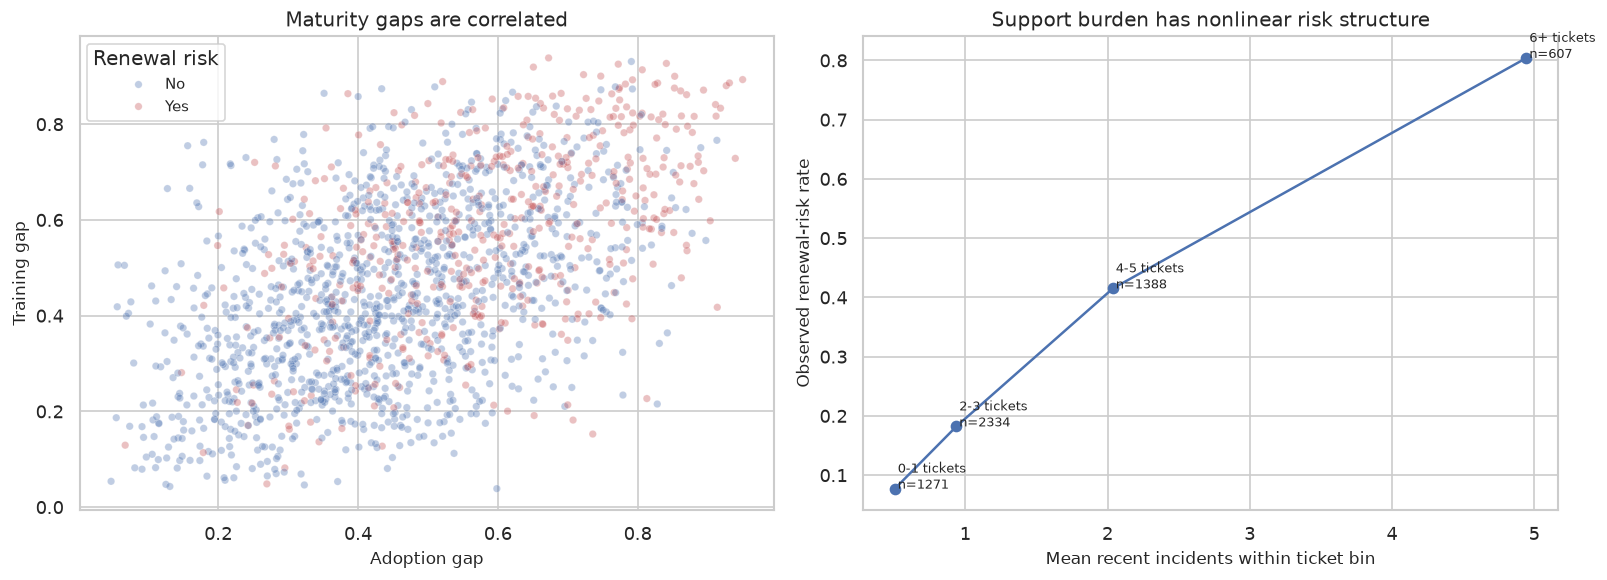

In [3]:
# Section focus: 3. Synthetic Decision Case: Renewal-Risk Triage.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

fig, axes = plt.subplots(1, 2, figsize=(13.6, 5.0))

plot_sample = df.sample(1700, random_state=RANDOM_SEED).copy()
plot_sample['renewal_risk_label'] = np.where(plot_sample[TARGET].eq(1), 'Yes', 'No')
sns.scatterplot(
    data=plot_sample,
    x='adoption_gap',
    y='training_gap',
    hue='renewal_risk_label',
    hue_order=['No', 'Yes'],
    palette={'No': '#4c72b0', 'Yes': '#c44e52'},
    alpha=0.35,
    s=20,
    ax=axes[0],
)
axes[0].set_title('Maturity gaps are correlated')
axes[0].set_xlabel('Adoption gap')
axes[0].set_ylabel('Training gap')
axes[0].legend(title='Renewal risk', loc='upper left')

ticket_bins = pd.cut(df['support_tickets_30d'], bins=[-0.1, 1, 3, 5, 20], labels=['0-1 tickets', '2-3 tickets', '4-5 tickets', '6+ tickets'])
burden_summary = (
    df.assign(ticket_bin=ticket_bins)
    .groupby('ticket_bin', observed=True)
    .agg(
        observed_risk_rate=(TARGET, 'mean'),
        mean_incidents=('recent_incidents_90d', 'mean'),
        rows=(TARGET, 'size'),
    )
    .reset_index()
)
axes[1].plot(burden_summary['mean_incidents'], burden_summary['observed_risk_rate'], marker='o', color='#4c72b0')
for _, row in burden_summary.iterrows():
    axes[1].text(row['mean_incidents'] + 0.02, row['observed_risk_rate'], f"{row['ticket_bin']}\nn={int(row['rows'])}", fontsize=8)
axes[1].set_title('Support burden has nonlinear risk structure')
axes[1].set_xlabel('Mean recent incidents within ticket bin')
axes[1].set_ylabel('Observed renewal-risk rate')
plt.tight_layout()
plt.show()


Use Synthetic Decision Case: Renewal-Risk Triage to test whether the explanation story is credible. The displayed reasons should line up with the data-generating story and the operating decision, and unstable attributions should be called out clearly.


### Discussion of the Data Design

The left plot shows that maturity signals move together. The right plot shows that support burden has a nonlinear relationship with observed risk. These two properties create the main LIME tension:

- a local linear model can be useful near one account;
- but the explanation depends on which local neighborhood we generate;
- and independent perturbations may create feature combinations that do not resemble real accounts.

The local explanation problem is intentionally placed in a correlated feature space. LIME works by fitting a simple model around a case, so the generated neighborhood matters. If perturbations break realistic relationships among usage, training, tickets, and incidents, the local surrogate can explain the model in a neighborhood that the business would never observe.

That is the experiment here. We compare local explanations while changing how the neighborhood is generated and how much locality is imposed. The dataset is realistic enough that these choices affect the story an analyst would tell about a single account.


## 4. Fit A Black-Box Model And A Transparent Reference

LIME is model-agnostic. It only needs a prediction function. We will fit a gradient boosting model as the black box and keep a logistic regression model as a transparent reference.


In [4]:
# Section focus: 4. Fit A Black-Box Model And A Transparent Reference.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def predict_risk(model, X_input):
    """Carry out the predict risk step used in the 09. LIME, Local Surrogates, and Neighborhood Sensitivity workflow.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by this step.
    X_input : object
        Feature row, feature matrix, or covariate value passed into the model workflow.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the predict risk calculation.
    """
    return model.predict_proba(X_input)[:, 1]

logit_model = Pipeline(
    steps=[
        ('scale', StandardScaler()),
        ('model', LogisticRegression(max_iter=800, C=0.9, random_state=RANDOM_SEED)),
    ]
)

rf_model = RandomForestClassifier(
    n_estimators=220,
    min_samples_leaf=35,
    max_features='sqrt',
    random_state=RANDOM_SEED,
    n_jobs=1,
)

gbm_model = HistGradientBoostingClassifier(
    max_iter=230,
    learning_rate=0.045,
    max_leaf_nodes=26,
    min_samples_leaf=42,
    l2_regularization=0.03,
    random_state=RANDOM_SEED,
)

models = {
    'Logistic regression': logit_model,
    'Random forest': rf_model,
    'Gradient boosting': gbm_model,
}

metric_rows = []
for model_name, model in models.items():
    model.fit(X_train, y_train)
    pred = predict_risk(model, X_test)
    metric_rows.append(
        {
            'model': model_name,
            'roc_auc': roc_auc_score(y_test, pred),
            'average_precision': average_precision_score(y_test, pred),
            'brier_score': brier_score_loss(y_test, pred),
            'log_loss': log_loss(y_test, pred),
            'mean_predicted_risk': pred.mean(),
        }
    )
metrics = pd.DataFrame(metric_rows).sort_values('roc_auc', ascending=False)
smart_display(metrics.round(3))


,model,roc_auc,average_precision,brier_score,log_loss,mean_predicted_risk
0,Logistic regression,0.856,0.767,0.124,0.396,0.273
1,Random forest,0.850,0.758,0.127,0.410,0.273
2,Gradient boosting,0.841,0.747,0.130,0.422,0.274


This result is an interpretation diagnostic. For Fit A Black-Box Model And A Transparent Reference, look at whether the explanation is stable, plausible, and useful for stakeholder review. When the takeaway changes with the setup, the report should avoid sounding definitive.


### Discussion of Predictive Performance

The black-box model has enough predictive signal to be worth explaining. But the performance table is also a warning: explanations should not be used to decorate a weak model. A local explanation of a bad model is still an explanation of a bad model.


## 5. Build A LIME-Style Explainer From Scratch

The implementation below has four parts:

1. Generate perturbed points around $x_0$.
2. Compute distances between perturbed points and $x_0$ in standardized feature space.
3. Convert distances into kernel weights.
4. Fit a weighted ridge regression to approximate the black-box predictions locally.

The fitted coefficients are the local explanation. The weighted $R^2$ is the local fidelity diagnostic.


In [5]:
# Section focus: 5. Build A LIME-Style Explainer From Scratch.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

feature_means = X_train.mean()
feature_stds = X_train.std().replace(0, 1)
feature_mins = X_train.min()
feature_maxs = X_train.max()

COUNT_FEATURES = ['support_tickets_30d', 'recent_incidents_90d']
BINARY_FEATURES = ['executive_sponsor', 'international_region']


def coerce_to_feature_domain(samples):
    """Carry out the coerce to feature domain step used in the 09. LIME, Local Surrogates, and Neighborhood Sensitivity workflow.
    
    Parameters
    ----------
    samples : object
        Repeated samples used to study variability or stability.
    
    Returns
    -------
    object
        Intermediate result produced by the coerce to feature domain calculation and reused by later cells.
    """
    samples = samples.copy()
    for feature in FEATURES:
        samples[feature] = samples[feature].clip(feature_mins[feature], feature_maxs[feature])
    for feature in COUNT_FEATURES:
        samples[feature] = np.round(samples[feature]).clip(feature_mins[feature], feature_maxs[feature])
    for feature in BINARY_FEATURES:
        samples[feature] = (samples[feature] >= 0.5).astype(int)
    return samples


def generate_lime_neighborhood(x0, n_samples=2200, sampling='independent', local_scale=0.75, seed=2060):
    """Generate lime neighborhood for the 09. LIME, Local Surrogates, and Neighborhood Sensitivity workflow.
    
    Parameters
    ----------
    x0 : object
        The x0 setting that controls the lime neighborhood calculation in this notebook.
    n_samples : object
        Number of sampled observations used by the simulation or estimator.
    sampling : object
        Sampling specification used to draw cases or resamples.
    local_scale : object
        The local scale setting that controls the lime neighborhood calculation in this notebook.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        Intermediate result produced by the lime neighborhood calculation and reused by later cells.
    """
    rng_local = np.random.default_rng(seed)
    x0 = x0[FEATURES].astype(float)

    if sampling == 'independent':
        raw = rng_local.normal(
            loc=x0.to_numpy(),
            scale=(local_scale * feature_stds[FEATURES]).to_numpy(),
            size=(n_samples, len(FEATURES)),
        )
    elif sampling == 'covariance':
        covariance = np.cov(X_train[FEATURES].to_numpy(), rowvar=False)
        covariance = covariance * (local_scale ** 2) + np.eye(len(FEATURES)) * 1e-5
        raw = rng_local.multivariate_normal(mean=x0.to_numpy(), cov=covariance, size=n_samples)
    elif sampling == 'empirical':
        sampled = X_train[FEATURES].sample(n_samples, replace=True, random_state=seed).reset_index(drop=True)
        noise = rng_local.normal(0, local_scale * 0.12, size=sampled.shape) * feature_stds[FEATURES].to_numpy()
        raw = 0.65 * x0.to_numpy() + 0.35 * sampled.to_numpy() + noise
    else:
        raise ValueError(f'Unknown sampling design: {sampling}')

    samples = pd.DataFrame(raw, columns=FEATURES)
    samples = coerce_to_feature_domain(samples)
    samples.iloc[0, :] = x0.to_numpy()
    return samples


def standardized_distance(samples, x0):
    """Carry out the standardized distance step used in the 09. LIME, Local Surrogates, and Neighborhood Sensitivity workflow.
    
    Parameters
    ----------
    samples : object
        Repeated samples used to study variability or stability.
    x0 : object
        The x0 setting that controls the standardized distance calculation in this notebook.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the standardized distance calculation.
    """
    z = (samples[FEATURES] - x0[FEATURES].to_numpy()) / feature_stds[FEATURES].to_numpy()
    return np.sqrt((z ** 2).sum(axis=1))


def kernel_weights(distances, kernel_width=1.25):
    """Carry out the kernel weights step used in the 09. LIME, Local Surrogates, and Neighborhood Sensitivity workflow.
    
    Parameters
    ----------
    distances : object
        The distances setting that controls the kernel weights calculation in this notebook.
    kernel_width : object
        Display setting used to make the plot or table readable in the rendered notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the kernel weights calculation and reused by later cells.
    """
    return np.exp(-(distances ** 2) / (kernel_width ** 2))


def weighted_r2(y_true, y_pred, weights):
    """Carry out the weighted r2 step used in the 09. LIME, Local Surrogates, and Neighborhood Sensitivity workflow.
    
    Parameters
    ----------
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    y_pred : object
        Predicted target or outcome values compared against the observed values.
    weights : object
        Observation weights used to emphasize rows in an estimator or summary.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the weighted r2 calculation.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    weights = np.asarray(weights)
    y_bar = np.average(y_true, weights=weights)
    ss_res = np.sum(weights * (y_true - y_pred) ** 2)
    ss_tot = np.sum(weights * (y_true - y_bar) ** 2)
    if ss_tot <= 1e-12:
        return np.nan
    return 1 - ss_res / ss_tot


def effective_sample_size(weights):
    """Carry out the effective sample size step used in the 09. LIME, Local Surrogates, and Neighborhood Sensitivity workflow.
    
    Parameters
    ----------
    weights : object
        Observation weights used to emphasize rows in an estimator or summary.
    
    Returns
    -------
    object
        Intermediate result produced by the effective sample size calculation and reused by later cells.
    """
    weights = np.asarray(weights)
    return weights.sum() ** 2 / np.sum(weights ** 2)


def fit_lime_explanation(model, x0, n_samples=2200, sampling='independent', local_scale=0.75, kernel_width=1.25, alpha=0.015, seed=2060):
    """Fit the lime explanation model or object used in the 09. LIME, Local Surrogates, and Neighborhood Sensitivity analysis.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by this step.
    x0 : object
        The x0 setting that controls the lime explanation calculation in this notebook.
    n_samples : object
        Number of sampled observations used by the simulation or estimator.
    sampling : object
        Sampling specification used to draw cases or resamples.
    local_scale : object
        The local scale setting that controls the lime explanation calculation in this notebook.
    kernel_width : object
        Display setting used to make the plot or table readable in the rendered notebook.
    alpha : object
        Regularization, smoothing, or significance parameter used by the calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    samples = generate_lime_neighborhood(x0, n_samples=n_samples, sampling=sampling, local_scale=local_scale, seed=seed)
    black_box_pred = predict_risk(model, samples)
    distances = standardized_distance(samples, x0)
    weights = kernel_weights(distances, kernel_width=kernel_width)

    X_local = ((samples[FEATURES] - x0[FEATURES].to_numpy()) / feature_stds[FEATURES].to_numpy()).to_numpy()
    surrogate = Ridge(alpha=alpha, fit_intercept=True)
    surrogate.fit(X_local, black_box_pred, sample_weight=weights)
    surrogate_pred = surrogate.predict(X_local)

    explanation = pd.DataFrame(
        {
            'feature': FEATURES,
            'feature_label': [FEATURE_LABELS[f] for f in FEATURES],
            'local_coefficient_per_sd_shift': surrogate.coef_,
            'abs_local_coefficient': np.abs(surrogate.coef_),
            'x0_value': x0[FEATURES].to_numpy(dtype=float),
        }
    ).sort_values('abs_local_coefficient', ascending=False)

    diagnostics = {
        'sampling': sampling,
        'kernel_width': kernel_width,
        'local_scale': local_scale,
        'n_samples': n_samples,
        'effective_sample_size': effective_sample_size(weights),
        'black_box_prediction_x0': float(predict_risk(model, x0[FEATURES].to_frame().T)[0]),
        'surrogate_prediction_x0': float(surrogate.predict(np.zeros((1, len(FEATURES))))[0]),
        'local_weighted_r2': weighted_r2(black_box_pred, surrogate_pred, weights),
        'unweighted_r2': r2_score(black_box_pred, surrogate_pred),
        'mean_weight': weights.mean(),
        'median_distance': float(np.median(distances)),
    }

    local_data = samples.copy()
    local_data['black_box_prediction'] = black_box_pred
    local_data['surrogate_prediction'] = surrogate_pred
    local_data['distance'] = distances
    local_data['weight'] = weights
    return explanation, diagnostics, local_data, surrogate


## 6. Explain One High-Risk Account

We choose a high-risk account and fit a local surrogate around it. The coefficients below are slopes in standardized local feature space. A coefficient of `0.05` means a one-standard-deviation local increase in that feature changes the surrogate prediction by about five percentage points, holding the other surrogate features fixed.


In [6]:
# Section focus: 6. Explain One High-Risk Account.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

test_predictions = pd.Series(predict_risk(gbm_model, X_test), index=X_test.index, name='predicted_risk')
focus_index = test_predictions.sub(0.82).abs().sort_values().index[0]
x_focus = X_test.loc[focus_index]

focus_profile = pd.DataFrame(
    [
        {
            'row_index': focus_index,
            'observed_outcome': int(y_test.loc[focus_index]),
            'black_box_prediction': test_predictions.loc[focus_index],
            **{FEATURE_LABELS[f]: x_focus[f] for f in FEATURES},
        }
    ]
)
smart_display(focus_profile.round(3), max_width='420px')

lime_explanation, lime_diagnostics, lime_local_data, lime_surrogate = fit_lime_explanation(
    gbm_model,
    x_focus,
    n_samples=2400,
    sampling='independent',
    local_scale=0.72,
    kernel_width=1.20,
    alpha=0.02,
    seed=2061,
)
smart_display(pd.DataFrame([lime_diagnostics]).round(4))
smart_display(lime_explanation[['feature_label', 'x0_value', 'local_coefficient_per_sd_shift']].round(4))


,row_index,observed_outcome,black_box_prediction,Adoption gap,Training gap,Support tickets in last 30 days,Recent incidents in last 90 days,Billing delay days,Executive sponsor present,International region,Random noise feature
0,571,1,0.820,0.644,0.638,5.000,5.000,2.775,1.000,1.000,-0.365


,sampling,kernel_width,local_scale,n_samples,effective_sample_size,black_box_prediction_x0,surrogate_prediction_x0,local_weighted_r2,unweighted_r2,mean_weight,median_distance
0,independent,1.200,0.720,2400,1187.968,0.820,0.815,0.564,0.607,0.173,1.757


,feature_label,x0_value,local_coefficient_per_sd_shift
3,Recent incidents in last 90 days,5.000,0.168
2,Support tickets in last 30 days,5.000,0.091
1,Training gap,0.638,0.060
0,Adoption gap,0.644,0.058
7,Random noise feature,-0.365,-0.040
5,Executive sponsor present,1.000,-0.022
4,Billing delay days,2.775,0.016
6,International region,1.000,-0.009


The explanation result should be compared with the decision story. In Explain One High-Risk Account, stable features, changing local reasons, and disagreement across explainers tell us how much trust to place in the model narrative. When the explanation is weak, human reviewers have to reconstruct the reasoning themselves.


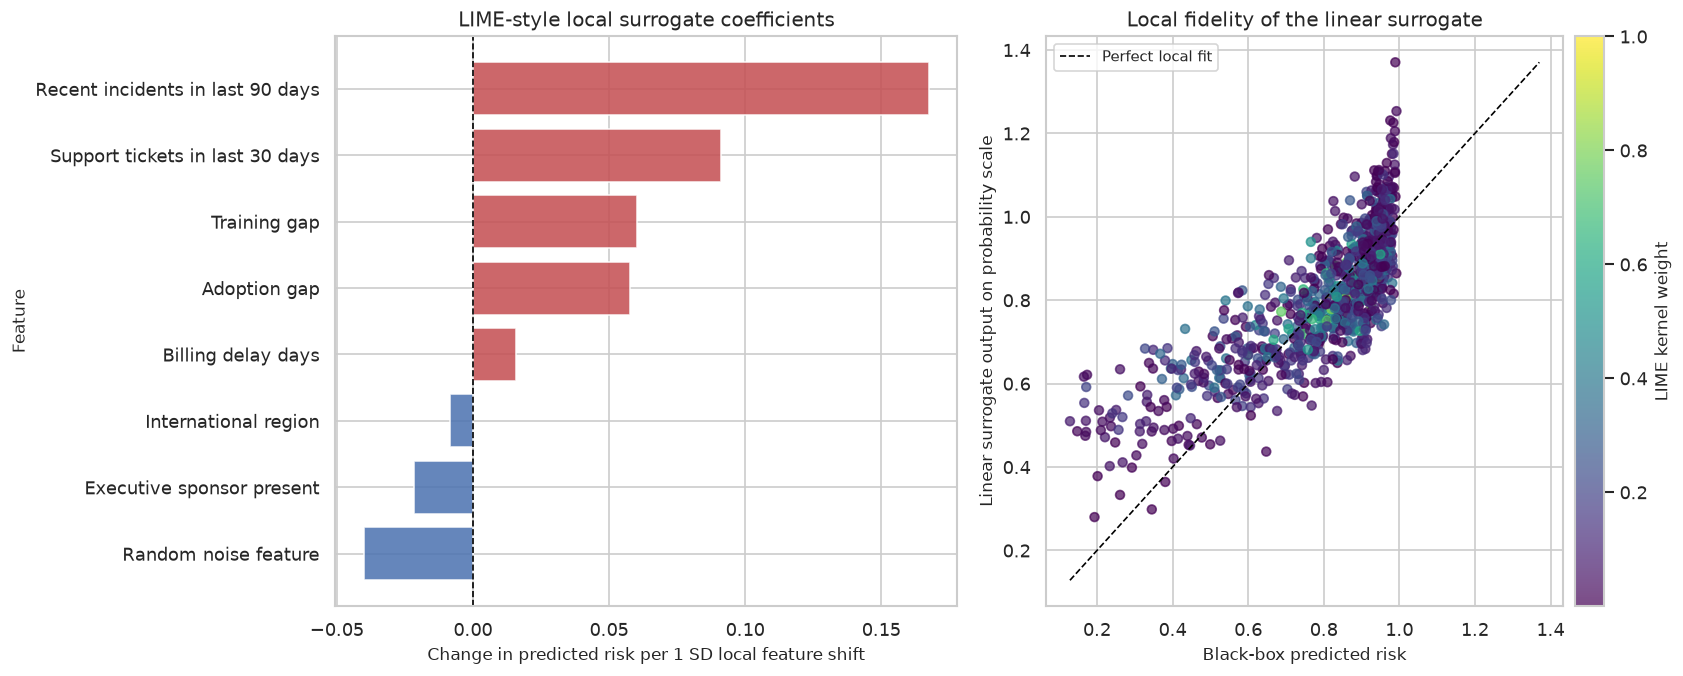

In [7]:
# Section focus: 6. Explain One High-Risk Account.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

plot_exp = lime_explanation.sort_values('local_coefficient_per_sd_shift', ascending=True)
colors = np.where(plot_exp['local_coefficient_per_sd_shift'] >= 0, '#c44e52', '#4c72b0')

fig, axes = plt.subplots(1, 2, figsize=(14.2, 5.8))
axes[0].barh(plot_exp['feature_label'], plot_exp['local_coefficient_per_sd_shift'], color=colors, alpha=0.86)
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('LIME-style local surrogate coefficients')
axes[0].set_xlabel('Change in predicted risk per 1 SD local feature shift')
axes[0].set_ylabel('Feature')

sample_for_scatter = lime_local_data.sample(900, random_state=RANDOM_SEED)
scatter = axes[1].scatter(
    sample_for_scatter['black_box_prediction'],
    sample_for_scatter['surrogate_prediction'],
    c=sample_for_scatter['weight'],
    cmap='viridis',
    alpha=0.70,
    s=28,
)
lims = [
    min(sample_for_scatter['black_box_prediction'].min(), sample_for_scatter['surrogate_prediction'].min()),
    max(sample_for_scatter['black_box_prediction'].max(), sample_for_scatter['surrogate_prediction'].max()),
]
axes[1].plot(lims, lims, color='black', linestyle='--', linewidth=1, label='Perfect local fit')
axes[1].set_title('Local fidelity of the linear surrogate')
axes[1].set_xlabel('Black-box predicted risk')
axes[1].set_ylabel('Linear surrogate output on probability scale')
axes[1].legend(loc='upper left')
cbar = fig.colorbar(scatter, ax=axes[1], pad=0.02)
cbar.set_label('LIME kernel weight')
plt.tight_layout()
plt.show()


Use the explanation as a stress test of the model narrative. In Explain One High-Risk Account, the displayed reasons should make sense with the data-generating story and the operating decision. Different explanation views can imply different decisions, so the uncertainty belongs in the main story.


### Discussion of the Local Explanation

The local surrogate tells us which directions around this account most change the black-box prediction. In this run, recent incidents, support tickets, and maturity gaps should usually dominate because this account is in a high-burden region of the feature space.

The local fidelity scatter is as important as the coefficient chart. A coefficient chart without a local fidelity diagnostic is only half an explanation. If the surrogate does not approximate the black-box model well near $x_0$, its coefficients should not be trusted.

Because this surrogate is an ordinary linear approximation fitted to probability outputs, some low-weight perturbed points can receive surrogate values outside the probability range. That is another reminder that the surrogate is an approximation device, not a calibrated replacement for the black-box model.


## 7. Kernel Width Sensitivity

The kernel width controls how local the explanation is.

- A very small kernel uses only points extremely close to $x_0$ and may have high variance.
- A very large kernel becomes less local and may average over several different response regimes.
- The “right” width is not purely statistical; it depends on what local means for the decision.

We fit several LIME explanations with the same perturbation design but different kernel widths.


In [8]:
kernel_widths = [0.55, 0.85, 1.20, 1.80, 2.60]
width_rows = []
width_explanations = []
for width in kernel_widths:
    exp, diag, _, _ = fit_lime_explanation(
        gbm_model,
        x_focus,
        n_samples=2400,
        sampling='independent',
        local_scale=0.72,
        kernel_width=width,
        alpha=0.02,
        seed=2061,
    )
    width_rows.append(diag)
    tmp = exp[['feature', 'feature_label', 'local_coefficient_per_sd_shift']].copy()
    tmp['kernel_width'] = width
    width_explanations.append(tmp)

width_diagnostics = pd.DataFrame(width_rows)
width_long = pd.concat(width_explanations, ignore_index=True)
smart_display(width_diagnostics[['kernel_width', 'effective_sample_size', 'local_weighted_r2', 'surrogate_prediction_x0', 'black_box_prediction_x0']].round(4))


,kernel_width,effective_sample_size,local_weighted_r2,surrogate_prediction_x0,black_box_prediction_x0
0,0.550,125.461,0.488,0.843,0.820
1,0.850,581.151,0.522,0.826,0.820
2,1.200,1187.968,0.564,0.815,0.820
3,1.800,1853.000,0.597,0.806,0.820
4,2.600,2203.993,0.613,0.801,0.820


For Kernel Width Sensitivity, read the explanation as something a stakeholder may challenge. Stability, clarity, and sensitivity all matter.


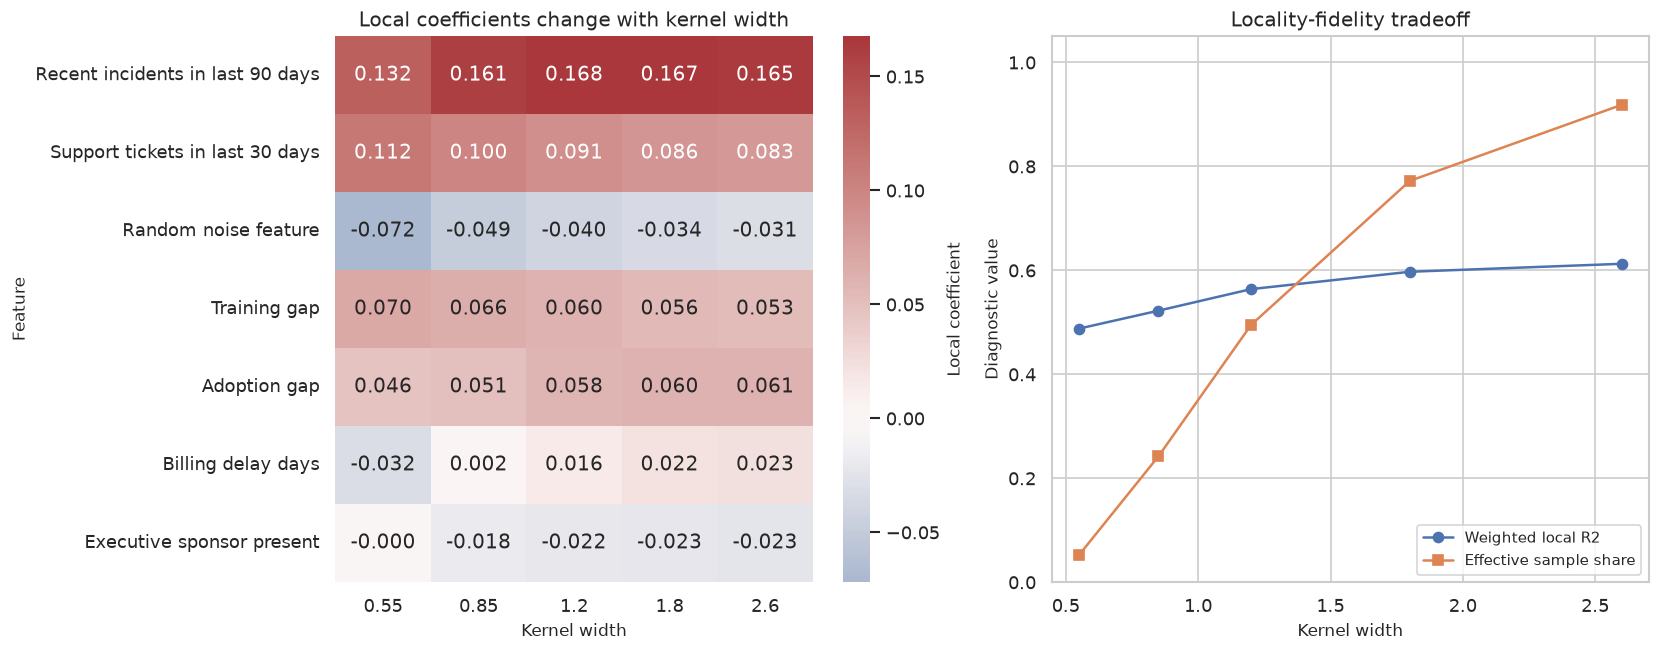

In [9]:
# Section focus: 7. Kernel Width Sensitivity.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

top_features_for_width = (
    width_long.groupby(['feature', 'feature_label'])['local_coefficient_per_sd_shift']
    .apply(lambda s: np.max(np.abs(s)))
    .sort_values(ascending=False)
    .head(7)
    .reset_index()['feature']
    .tolist()
)
width_plot = width_long.loc[width_long['feature'].isin(top_features_for_width)].copy()
width_pivot = width_plot.pivot_table(
    index='feature_label',
    columns='kernel_width',
    values='local_coefficient_per_sd_shift',
)
width_pivot = width_pivot.loc[
    width_pivot.abs().max(axis=1).sort_values(ascending=False).index
]

fig, axes = plt.subplots(1, 2, figsize=(14.0, 5.6))
sns.heatmap(
    width_pivot,
    annot=True,
    fmt='.3f',
    cmap='vlag',
    center=0,
    ax=axes[0],
    cbar_kws={'label': 'Local coefficient'},
)
axes[0].set_title('Local coefficients change with kernel width')
axes[0].set_xlabel('Kernel width')
axes[0].set_ylabel('Feature')

axes[1].plot(width_diagnostics['kernel_width'], width_diagnostics['local_weighted_r2'], marker='o', label='Weighted local R2')
axes[1].plot(width_diagnostics['kernel_width'], width_diagnostics['effective_sample_size'] / width_diagnostics['n_samples'], marker='s', label='Effective sample share')
axes[1].set_title('Locality-fidelity tradeoff')
axes[1].set_xlabel('Kernel width')
axes[1].set_ylabel('Diagnostic value')
axes[1].set_ylim(0, 1.05)
axes[1].legend(loc='lower right')
plt.tight_layout()
plt.show()


Kernel Width Sensitivity is useful only if the explanation remains credible under reasonable modeling choices.


### Discussion of Kernel Width

If the coefficient signs or rankings change substantially across plausible kernel widths, the explanation is fragile. LIME can still be useful, but the report should avoid presenting a single chart as a stable fact.

A strong LIME report includes both the coefficient chart and the sensitivity table. The sensitivity table tells the reader how much of the explanation comes from the analyst's neighborhood choice.


## 8. Perturbation Design Sensitivity

LIME also depends on the perturbation distribution. For tabular data, this is a major practical issue.

We compare three perturbation designs:

| Design | What it does | Risk |
|---|---|---|
| Independent Gaussian | Perturbs each feature independently around $x_0$ | Can break correlations and create unrealistic accounts |
| Covariance-aware Gaussian | Uses training covariance to preserve some dependence | Still Gaussian and may mishandle counts/binary variables |
| Empirical blend | Mixes $x_0$ with sampled training rows plus small noise | More realistic but less centered exactly on $x_0$ |


In [10]:
# Section focus: 8. Perturbation Design Sensitivity.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

sampling_designs = ['independent', 'covariance', 'empirical']
design_rows = []
design_explanations = []
for design in sampling_designs:
    exp, diag, local_data, _ = fit_lime_explanation(
        gbm_model,
        x_focus,
        n_samples=2600,
        sampling=design,
        local_scale=0.72,
        kernel_width=1.20,
        alpha=0.02,
        seed=2063,
    )
    plausibility = {
        'corr_adoption_training_in_neighborhood': local_data[['adoption_gap', 'training_gap']].corr().iloc[0, 1],
        'corr_tickets_incidents_in_neighborhood': local_data[['support_tickets_30d', 'recent_incidents_90d']].corr().iloc[0, 1],
    }
    design_rows.append({**diag, **plausibility})
    tmp = exp[['feature', 'feature_label', 'local_coefficient_per_sd_shift']].copy()
    tmp['sampling'] = design
    design_explanations.append(tmp)

design_diagnostics = pd.DataFrame(design_rows)
design_long = pd.concat(design_explanations, ignore_index=True)
smart_display(design_diagnostics[['sampling', 'effective_sample_size', 'local_weighted_r2', 'corr_adoption_training_in_neighborhood', 'corr_tickets_incidents_in_neighborhood']].round(4))


,sampling,effective_sample_size,local_weighted_r2,corr_adoption_training_in_neighborhood,corr_tickets_incidents_in_neighborhood
0,independent,1326.164,0.536,0.027,0.018
1,covariance,1337.315,0.619,0.550,0.683
2,empirical,2068.017,0.661,0.532,0.569


Use the explanation as a stress test of the model narrative. In Perturbation Design Sensitivity, the displayed reasons should make sense with the data-generating story and the operating decision. Local disagreement across methods should trigger a closer review of the case.


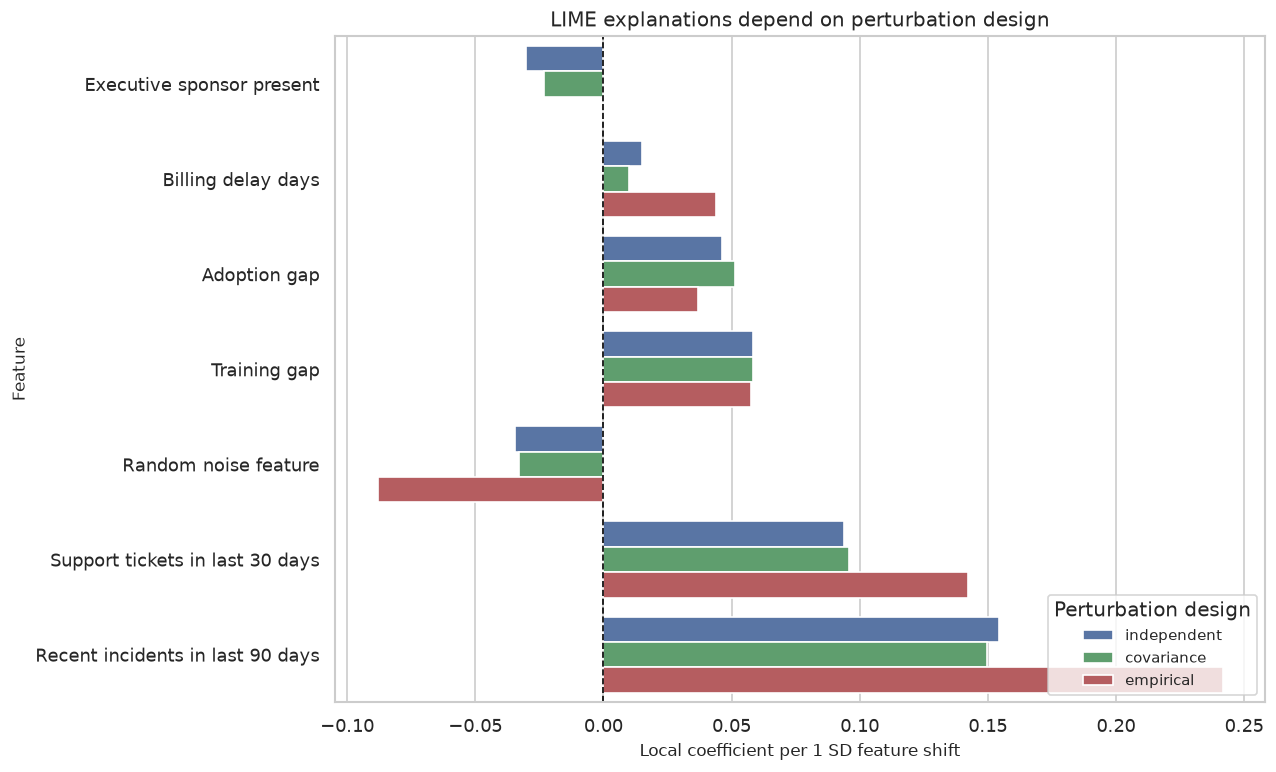

In [11]:
design_plot = design_long.loc[design_long['feature'].isin(top_features_for_width)].copy()
design_plot['feature_label'] = pd.Categorical(
    design_plot['feature_label'],
    categories=[FEATURE_LABELS[f] for f in top_features_for_width[::-1]],
    ordered=True,
)

fig, ax = plt.subplots(figsize=(10.8, 6.6))
sns.barplot(
    data=design_plot,
    y='feature_label',
    x='local_coefficient_per_sd_shift',
    hue='sampling',
    ax=ax,
    palette=['#4c72b0', '#55a868', '#c44e52'],
)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('LIME explanations depend on perturbation design')
ax.set_xlabel('Local coefficient per 1 SD feature shift')
ax.set_ylabel('Feature')
ax.legend(title='Perturbation design', loc='lower right')
plt.tight_layout()
plt.show()


Perturbation Design Sensitivity is a check on the model narrative. The explanation is useful when the reasons fit the data story, the decision context, and the limits of the method.


### Discussion of Perturbation Design

The perturbation design determines what local world the surrogate sees. If independent perturbations break the relationship between maturity variables or support-burden variables, the local coefficients can describe behavior in an artificial neighborhood.

This is the LIME analogue of the SHAP background problem. A local explanation depends on the model, the row, the perturbation distribution, and the kernel.


## 9. Randomness And Explanation Stability

LIME explanations are often stochastic because the perturbation samples are random. We now repeat the same explanation many times with different seeds.

The goal is not to eliminate randomness completely. The goal is to measure whether the explanation is stable enough to report.


In [12]:
# Section focus: 9. Randomness And Explanation Stability.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

stability_rows = []
for seed in range(2080, 2105):
    exp, diag, _, _ = fit_lime_explanation(
        gbm_model,
        x_focus,
        n_samples=1500,
        sampling='independent',
        local_scale=0.72,
        kernel_width=1.20,
        alpha=0.02,
        seed=seed,
    )
    top_feature = exp.iloc[0]['feature_label']
    for _, row in exp.iterrows():
        stability_rows.append(
            {
                'seed': seed,
                'feature': row['feature'],
                'feature_label': row['feature_label'],
                'local_coefficient': row['local_coefficient_per_sd_shift'],
                'abs_local_coefficient': abs(row['local_coefficient_per_sd_shift']),
                'top_feature_for_seed': top_feature,
                'local_weighted_r2': diag['local_weighted_r2'],
            }
        )

stability = pd.DataFrame(stability_rows)
stability_summary = (
    stability.groupby(['feature', 'feature_label'], as_index=False)
    .agg(
        mean_coefficient=('local_coefficient', 'mean'),
        sd_coefficient=('local_coefficient', 'std'),
        p05=('local_coefficient', lambda x: np.quantile(x, 0.05)),
        p95=('local_coefficient', lambda x: np.quantile(x, 0.95)),
        top_feature_share=('top_feature_for_seed', lambda x: np.mean(x == x.name if False else 0)),
    )
)
# Compute top-feature frequency separately because groupby aggregation cannot easily access the feature label.
top_counts = (
    stability[['seed', 'top_feature_for_seed']]
    .drop_duplicates()
    .value_counts('top_feature_for_seed')
    .rename_axis('feature_label')
    .reset_index(name='top_count')
)
top_counts['top_feature_share'] = top_counts['top_count'] / stability['seed'].nunique()
stability_summary = stability_summary.drop(columns=['top_feature_share']).merge(
    top_counts[['feature_label', 'top_feature_share']],
    on='feature_label',
    how='left',
).fillna({'top_feature_share': 0})
stability_summary = stability_summary.sort_values('mean_coefficient', key=lambda s: np.abs(s), ascending=False)
smart_display(stability_summary.round(4))


,feature,feature_label,mean_coefficient,sd_coefficient,p05,p95,top_feature_share
5,recent_incidents_90d,Recent incidents in last 90 days,0.158,0.007,0.147,0.168,1.000
6,support_tickets_30d,Support tickets in last 30 days,0.099,0.005,0.090,0.107,0.000
7,training_gap,Training gap,0.058,0.004,0.050,0.064,0.000
0,adoption_gap,Adoption gap,0.054,0.006,0.044,0.062,0.000
4,random_noise_feature,Random noise feature,-0.034,0.006,-0.044,-0.026,0.000
2,executive_sponsor,Executive sponsor present,-0.026,0.005,-0.035,-0.017,0.000
1,billing_delay_days,Billing delay days,0.011,0.007,0.004,0.021,0.000
3,international_region,International region,-0.006,0.007,-0.016,0.006,0.000


The explanation result should be compared with the decision story. In Randomness And Explanation Stability, stable features, changing local reasons, and disagreement across explainers tell us how much trust to place in the model narrative. A good explanation makes the recommendation easier to challenge, revise, or defend.


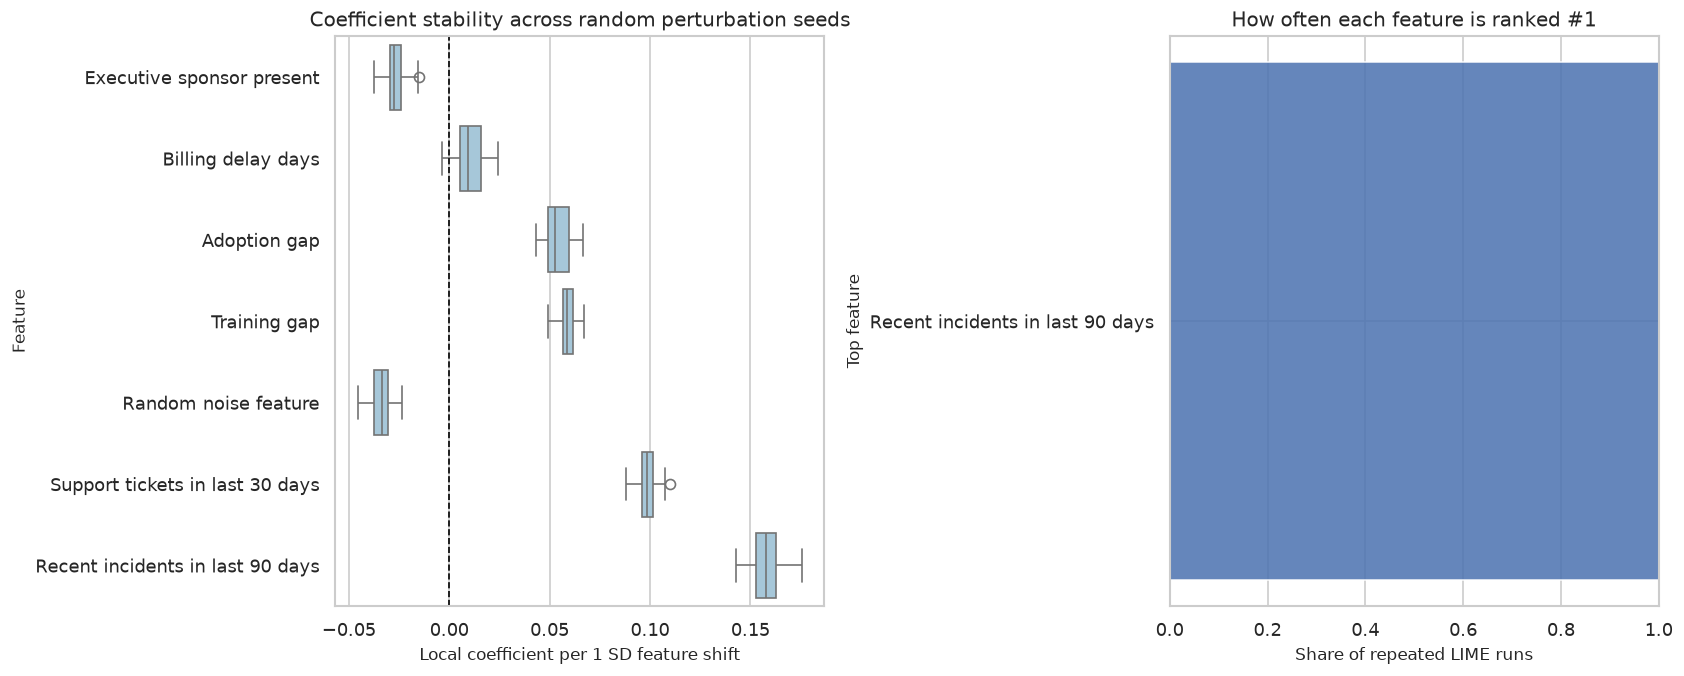

In [13]:
# Section focus: 9. Randomness And Explanation Stability.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

stability_plot = stability.loc[stability['feature'].isin(top_features_for_width)].copy()
stability_plot['feature_label'] = pd.Categorical(
    stability_plot['feature_label'],
    categories=[FEATURE_LABELS[f] for f in top_features_for_width[::-1]],
    ordered=True,
)

fig, axes = plt.subplots(1, 2, figsize=(14.2, 5.8))
sns.boxplot(
    data=stability_plot,
    y='feature_label',
    x='local_coefficient',
    color='#9ecae1',
    ax=axes[0],
)
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Coefficient stability across random perturbation seeds')
axes[0].set_xlabel('Local coefficient per 1 SD feature shift')
axes[0].set_ylabel('Feature')

top_frequency = top_counts.sort_values('top_feature_share', ascending=True)
axes[1].barh(top_frequency['feature_label'], top_frequency['top_feature_share'], color='#4c72b0', alpha=0.86)
axes[1].set_title('How often each feature is ranked #1')
axes[1].set_xlabel('Share of repeated LIME runs')
axes[1].set_ylabel('Top feature')
axes[1].set_xlim(0, 1)
plt.tight_layout()
plt.show()


Use the explanation as a stress test of the model narrative. In Randomness And Explanation Stability, the displayed reasons should make sense with the data-generating story and the operating decision. The analyst should treat explanation disagreement as evidence about reliability.


### Discussion of Stability

If a feature is ranked first in nearly every run, the local story is more stable. If several features trade places, the report should say so.

This is one reason local explanations can feel brittle in production. The chart may look deterministic, but the workflow behind the chart may contain random sampling, kernel choices, and surrogate regularization choices.


## 10. Similar Accounts Can Have Different Local Stories

A local explanation is attached to a point. Two nearby accounts can receive different explanations if they sit on different sides of a nonlinear threshold or if the black-box model changes slope locally.

We identify accounts near the focus account and compare their local surrogate explanations.


In [14]:
# Section focus: 10. Similar Accounts Can Have Different Local Stories.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def nearest_test_accounts(x0, X_pool, n_neighbors=4):
    """Carry out the nearest test accounts step used in the 09. LIME, Local Surrogates, and Neighborhood Sensitivity workflow.
    
    Parameters
    ----------
    x0 : object
        The x0 setting that controls the nearest test accounts calculation in this notebook.
    X_pool : object
        Feature row, feature matrix, or covariate value passed into the model workflow.
    n_neighbors : object
        Count or size setting for the nearest test accounts calculation.
    
    Returns
    -------
    object
        Intermediate result produced by the nearest test accounts calculation and reused by later cells.
    """
    distances = standardized_distance(X_pool[FEATURES].reset_index(drop=True), x0[FEATURES])
    out = pd.DataFrame({'row_index': X_pool.index.to_numpy(), 'distance_to_focus': distances})
    out = out.loc[out['row_index'] != focus_index].sort_values('distance_to_focus').head(n_neighbors)
    return out

neighbors = nearest_test_accounts(x_focus, X_test, n_neighbors=4)
comparison_indices = [focus_index] + neighbors['row_index'].tolist()

nearby_rows = []
nearby_explanations = []
for idx in comparison_indices:
    x_row = X_test.loc[idx]
    exp, diag, _, _ = fit_lime_explanation(
        gbm_model,
        x_row,
        n_samples=1800,
        sampling='independent',
        local_scale=0.72,
        kernel_width=1.20,
        alpha=0.02,
        seed=2110 + int(idx) % 100,
    )
    label = 'Focus account' if idx == focus_index else f'Neighbor {len(nearby_rows)}'
    nearby_rows.append(
        {
            'account_label': label,
            'row_index': idx,
            'observed_outcome': int(y_test.loc[idx]),
            'black_box_prediction': diag['black_box_prediction_x0'],
            'distance_to_focus': 0 if idx == focus_index else float(neighbors.loc[neighbors['row_index'].eq(idx), 'distance_to_focus'].iloc[0]),
            'top_lime_feature': exp.iloc[0]['feature_label'],
            'local_weighted_r2': diag['local_weighted_r2'],
        }
    )
    tmp = exp[['feature', 'feature_label', 'local_coefficient_per_sd_shift']].copy()
    tmp['account_label'] = label
    nearby_explanations.append(tmp)

nearby_table = pd.DataFrame(nearby_rows)
nearby_long = pd.concat(nearby_explanations, ignore_index=True)
smart_display(nearby_table.round(4))


,account_label,row_index,observed_outcome,black_box_prediction,distance_to_focus,top_lime_feature,local_weighted_r2
0,Focus account,571,1,0.820,0.000,Recent incidents in last 90 days,0.568
1,Neighbor 1,1865,1,0.478,1.034,Recent incidents in last 90 days,0.688
2,Neighbor 2,2381,1,0.965,1.156,Recent incidents in last 90 days,0.414
3,Neighbor 3,901,1,0.930,1.351,Recent incidents in last 90 days,0.642
4,Neighbor 4,2531,1,0.925,1.432,Recent incidents in last 90 days,0.625


In Similar Accounts Can Have Different Local Stories, the explanation should help a reviewer understand what is stable, what is fragile, and what still needs checking. The report should make this sensitivity visible to the reader.


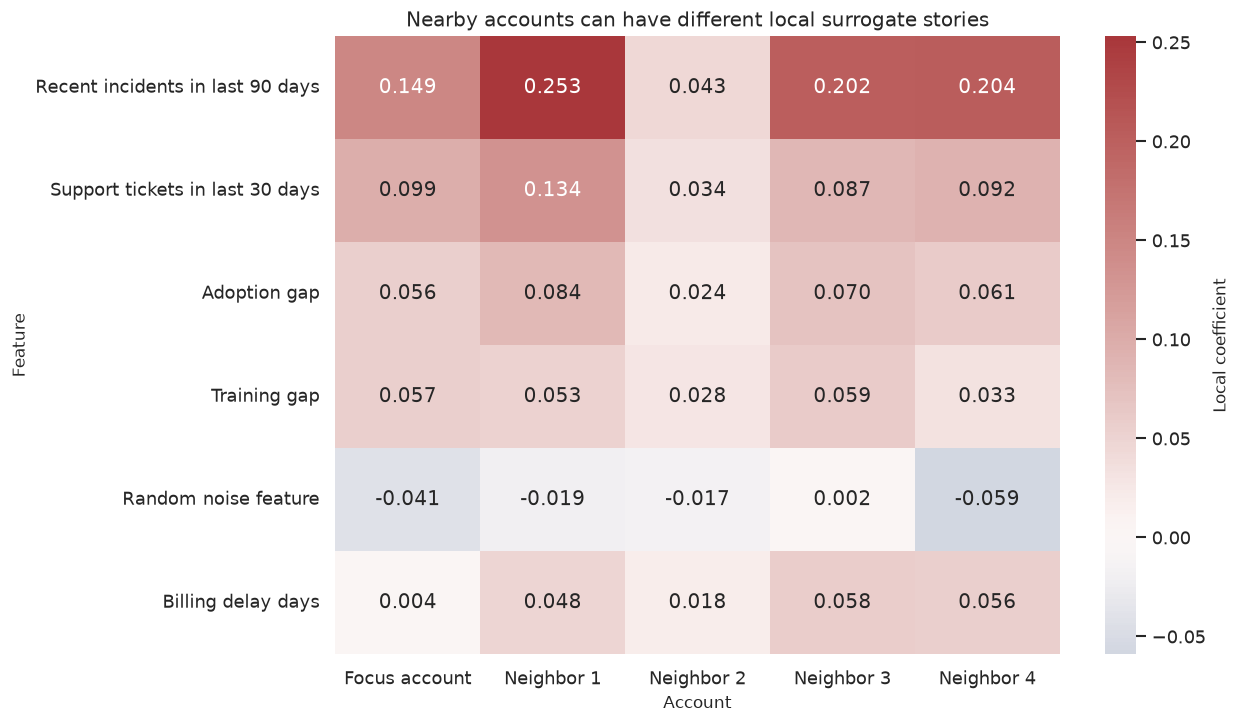

In [15]:
# Section focus: 10. Similar Accounts Can Have Different Local Stories.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

nearby_top_features = (
    nearby_long.groupby(['feature', 'feature_label'])['local_coefficient_per_sd_shift']
    .apply(lambda s: np.max(np.abs(s)))
    .sort_values(ascending=False)
    .head(6)
    .reset_index()['feature']
    .tolist()
)
nearby_plot = nearby_long.loc[nearby_long['feature'].isin(nearby_top_features)].copy()
nearby_pivot = nearby_plot.pivot_table(
    index='feature_label',
    columns='account_label',
    values='local_coefficient_per_sd_shift',
)
nearby_pivot = nearby_pivot.loc[nearby_pivot.abs().max(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(10.6, 6.2))
sns.heatmap(
    nearby_pivot,
    annot=True,
    fmt='.3f',
    cmap='vlag',
    center=0,
    ax=ax,
    cbar_kws={'label': 'Local coefficient'},
)
ax.set_title('Nearby accounts can have different local surrogate stories')
ax.set_xlabel('Account')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()


For Similar Accounts Can Have Different Local Stories, the right question is whether this explanation can survive baseline, sample, or neighborhood changes.


### Discussion of Nearby Accounts

This section guards against a common stakeholder mistake: taking one local explanation and treating it as a general rule. LIME explains a local neighborhood around one point. Nearby points can have similar explanations, but they are not guaranteed to.

If a decision workflow needs consistent reasons across a segment, the analyst should aggregate and audit many local explanations or use a more transparent segment-level model.


## 11. LIME, SHAP, And Permutation Importance Compared

| Method | Core object | Main strength | Main caveat |
|---|---|---|---|
| LIME | Weighted local surrogate around one point | Intuitive local approximation with explicit fidelity diagnostics | Sensitive to perturbation design and kernel width |
| SHAP | Additive Shapley attribution relative to a background | Additivity and principled feature-credit allocation | Sensitive to background and dependence assumptions |
| Permutation importance | Performance drop after feature disruption | Directly tied to held-out predictive reliance | Global and not a local explanation |

These methods are complementary. They should not be forced to agree perfectly because they answer different questions.


In [16]:
# Section focus: 11. LIME, SHAP, And Permutation Importance Compared.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

method_comparison = pd.DataFrame(
    [
        {
            'question': 'What does this individual prediction depend on locally?',
            'best_starting_tool': 'LIME or SHAP',
            'required_caveat': 'Report local fidelity and baseline/neighborhood choices',
        },
        {
            'question': 'Which features does the model rely on for held-out performance?',
            'best_starting_tool': 'Permutation importance',
            'required_caveat': 'Report metric, repeats, correlated-feature checks, and uncertainty',
        },
        {
            'question': 'Would changing this feature improve the real outcome?',
            'best_starting_tool': 'Causal design, not LIME',
            'required_caveat': 'Prediction explanations are not intervention effects',
        },
        {
            'question': 'Can I safely show this explanation to stakeholders?',
            'best_starting_tool': 'LIME plus stability/fidelity audit',
            'required_caveat': 'Include what the explanation is not allowed to mean',
        },
    ]
)
smart_display(method_comparison)


,question,best_starting_tool,required_caveat
0,What does this individual prediction depend on locally?,LIME or SHAP,Report local fidelity and baseline/neighborhood choices
1,Which features does the model rely on for held-out performance?,Permutation importance,"Report metric, repeats, correlated-feature checks, and uncertainty"
2,Would changing this feature improve the real outcome?,"Causal design, not LIME",Prediction explanations are not intervention effects
3,Can I safely show this explanation to stakeholders?,LIME plus stability/fidelity audit,Include what the explanation is not allowed to mean


Use the explanation as a stress test of the model narrative. In LIME, SHAP, And Permutation Importance Compared, the displayed reasons should make sense with the data-generating story and the operating decision. The explanation is still provisional when different methods tell different local stories.


## 12. Decision-Science Reporting Checklist

A professional LIME explanation should include:

| Reporting item | Why it matters |
|---|---|
| Black-box model and output scale | Coefficients explain this fitted model's predicted risk, not reality directly |
| Case being explained | Local explanations are point-specific |
| Perturbation design | Defines the neighborhood that the surrogate sees |
| Kernel width and distance metric | Controls how local the explanation is |
| Local fidelity | Tells whether the surrogate approximates the black box well enough |
| Stability checks | Shows whether the explanation survives random seeds and tuning choices |
| Plausibility checks | Tests whether perturbations resemble real data |
| Causal caveat | Prevents model sensitivity from being reported as an intervention effect |

For high-stakes settings, the explanation should be treated as evidence for model review, not as the whole decision justification.


## 13. Key Takeaways

- LIME fits a simple weighted surrogate model around one case.
- The coefficients explain the surrogate, which approximates the black-box model locally.
- Local fidelity is essential; a low-fidelity surrogate should not be interpreted.
- Kernel width changes how local the explanation is and can change coefficient rankings.
- Perturbation design matters because tabular features are often correlated and constrained.
- Repeated runs can reveal explanation instability that a single chart hides.
- Nearby accounts can have different local explanations in nonlinear regions.
- LIME explanations are not causal effects, action recommendations, or guarantees of fairness.
- A trustworthy LIME report includes neighborhood choices, local fidelity, stability checks, and explicit limits.


## References

- Li, Q., Cummings, R., & Mintz, Y. (2022). *Optimal local explainer aggregation for interpretable prediction*. *Proceedings of the AAAI Conference on Artificial Intelligence, 36*(11), 12000-12007. [https://doi.org/10.1609/aaai.v36i11.21458](https://doi.org/10.1609/aaai.v36i11.21458)
- Morales, C. G., Gisolfi, N., & Edman, R. (2022). *Actionable model-centric explanations*. *Proceedings of the AAAI Conference on Artificial Intelligence, 36*(11), 13019-13020. [https://doi.org/10.1609/aaai.v36i11.21646](https://doi.org/10.1609/aaai.v36i11.21646)
- Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). *“Why should I trust you?”: Explaining the predictions of any classifier*. Proceedings of NAACL-HLT Demonstrations, 97-101. [https://doi.org/10.18653/v1/N16-3020](https://doi.org/10.18653/v1/N16-3020)
- Ribeiro, M. T., Singh, S., & Guestrin, C. (2018). *Anchors: High-precision model-agnostic explanations*. *Proceedings of the AAAI Conference on Artificial Intelligence, 32*(1). [https://doi.org/10.1609/aaai.v32i1.11491](https://doi.org/10.1609/aaai.v32i1.11491)
- Zhao, X., Huang, W., & Huang, X. (2020). *BayLIME: Bayesian local interpretable model-agnostic explanations*. arXiv. [https://doi.org/10.48550/arXiv.2012.03058](https://doi.org/10.48550/arXiv.2012.03058)
